# EE 342 Final Project Lab Report  

**Team members:** Joanna Zhou, Yehoshua Luna, Noah Sanchez  

**Dataset used:** https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones  

## Setup

In [32]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Helper Functions

In [33]:
def compute_spectrograms(signal_tensor, n_fft=64, hop_length=4):
    """
    Converts a 3D time-series tensor into a 4D log-spectrogram tensor.
    Safely handles PyTorch STFT dimension requirements.

    Args:
        signal_tensor (Tensor): Input tensor of shape (Samples, Time, Channels).
        n_fft (int): Number of FFT points for STFT.
        hop_length (int): Hop length for STFT.
    
    Returns:
        Tensor: Log-spectrograms of shape (Samples, Channels, FreqBins, TimeFrames).
    """
    # Permute to (Samples, Channels, Time)
    signal_perm = signal_tensor.permute(0, 2, 1)
    
    # Extract dimensions for reshaping
    samples, channels, time_steps = signal_perm.shape
    
    # Flatten Samples and Channels into a single 2D batch dimension
    # Shape becomes: (Samples * Channels, Time) for PyTorch STFT
    signal_2d = signal_perm.reshape(samples * channels, time_steps)
    
    window = torch.hann_window(n_fft)
    
    # Compute the STFT
    stft_complex = torch.stft(
        signal_2d,
        n_fft=n_fft,
        hop_length=hop_length,
        window=window,
        return_complex=True
    )
    
    # Get magnitude and convert to Log Scale (Decibels)
    mag_spectrogram = torch.abs(stft_complex)
    log_spectrogram = 20 * torch.log10(mag_spectrogram + 1e-8)
    
    # Unflatten back to 4D: (Samples, Channels, FreqBins, TimeFrames)
    _, freq_bins, time_frames = log_spectrogram.shape
    final_spectrogram = log_spectrogram.reshape(samples, channels, freq_bins, time_frames)
    
    return final_spectrogram

In [34]:
def normalize_spectrograms(train_spec, test_spec):
    """
    Applies global Z-score normalization based on training data statistics.

    Args:
        train_spec (Tensor): Spectrograms from the training set, shape (Samples, Channels, FreqBins, TimeFrames).
        test_spec (Tensor): Spectrograms from the test set, same shape as train_spec

    Returns:
        train_spec_norm (Tensor): Normalized training spectrograms. Same shape as input.
        test_spec_norm (Tensor): Normalized test spectrograms. Same shape as input.
    """
    # Calculate mean and std ONLY from the training set
    mean = train_spec.mean(dim=(0, 2, 3), keepdim=True)
    std = train_spec.std(dim=(0, 2, 3), keepdim=True)
    
    # Add a tiny epsilon to prevent division by zero
    eps = 1e-8
    
    # Normalize both datasets using the TRAIN statistics
    train_spec_norm = (train_spec - mean) / (std + eps)
    test_spec_norm = (test_spec - mean) / (std + eps)
    
    return train_spec_norm, test_spec_norm

In [35]:
def plot_precomputed_spectrogram(spec_tensor, title="Spectrogram", sample_rate=50, hop_length=4):
    """
    Plots a precomputed 3-channel spectrogram tensor.
    
    Args:
        spec_tensor: 3D tensor of shape (3, FreqBins, TimeFrames)
        title: Title of the overall figure
        sample_rate: The original sampling rate in Hz
        hop_length: The hop length used during the STFT
    """
    # Convert to NumPy for Matplotlib
    if isinstance(spec_tensor, torch.Tensor):
        spec_tensor = spec_tensor.numpy()
        
    channels, freq_bins, time_frames = spec_tensor.shape
    
    # Calculate the physical bounds for the axes
    max_time = (time_frames * hop_length) / sample_rate
    nyquist_freq = sample_rate / 2
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    fig.suptitle(title, fontsize=14)
    
    axis_names = ['X-axis', 'Y-axis', 'Z-axis']
    
    for i in range(channels):
        im = axes[i].imshow(
            spec_tensor[i], 
            origin='lower', 
            aspect='auto', 
            cmap='magma', 
            extent=[0, max_time, 0, nyquist_freq]
        )
        
        axes[i].set_title(axis_names[i])
        axes[i].set_xlabel("Time (seconds)")
        if i == 0:
            axes[i].set_ylabel("Frequency (Hz)")
            
    # Add a unified colorbar
    fig.colorbar(im, ax=axes.ravel().tolist(), label="Magnitude (dB)", aspect=40)
    plt.show()

In [36]:
def plot_time_series(time_signal, title="Time Series", sample_rate=50):
    """
    Plots a 3-channel time-domain signal.
    
    Args:
        time_signal (torch.Tensor or np.ndarray): Time-domain signal with shape (Samples, Channels).
        title (str): Title for the plot.
        sample_rate (int): Sampling rate of the original signal in Hz (default is 50).
    
    Returns:
        None: Displays the plot of the time series.
    """
    # Convert to numpy if it's a PyTorch tensor
    if isinstance(time_signal, torch.Tensor):
        time_signal = time_signal.numpy()
        
    n_samples = time_signal.shape[0]
    time_axis = np.linspace(0, n_samples / sample_rate, n_samples)
    
    plt.figure(figsize=(12, 6))
    plt.plot(time_axis, time_signal)
    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend(['X-axis', 'Y-axis', 'Z-axis'], loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [37]:
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False):
    cm = np.array(cm, dtype=float)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sums, where=row_sums != 0)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")

    # title and axis labels
    ax.set_title(title, fontsize=14, pad=12, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    # ticks
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=30, ha="right", fontsize=10)
    ax.set_yticklabels(class_names, fontsize=10)

    # colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

    # grid-like cell borders
    ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # annotate cells
    threshold = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            ax.text(
                j, i, text,
                ha="center", va="center",
                color="white" if value > threshold else "black",
                fontsize=11, fontweight="bold"
            )

    plt.tight_layout()
    plt.show()

## Helper Classes

In [38]:
class HARDataLoader:
    """
    A management class for loading the UCI Human Activity Recognition Dataset.
    """

    def __init__(self, root_dir='data/raw', CNN=True):
        """
        Args:
            root_dir (str): Relative path to the raw data folder.
            CNN (bool): 
                True  -> return PyTorch tensors (for CNN)
                False -> return NumPy arrays (for Random Forest / sklearn)
        """
        self.root = Path(root_dir)
        self.CNN = CNN

    def _load_files_in_folder(self, folder_path, prefix, dataset_type):
        """
        Internal helper to combine X, Y, and Z axis text files into a 3D tensor/array.
        Returns shape: (samples, 128, 3)
        """
        axes = ['x', 'y', 'z']
        data = []

        for axis in axes:
            file_name = f'{prefix}_{axis}_{dataset_type}.txt'
            file_path = folder_path / file_name

            if not file_path.exists():
                raise FileNotFoundError(f"Missing expected data file: {file_path}")

            data_array = pd.read_csv(file_path, sep=r'\s+', header=None).values
            data.append(data_array)

        stacked = np.stack(data, axis=-1).astype(np.float32)

        if self.CNN:
            return torch.tensor(stacked, dtype=torch.float32)
        else:
            return stacked

    def get_split(self, split='train'):
        """
        Retrieves the accelerometer, gyroscope, and label data for a split.

        Args:
            split (str): 'train' or 'test'

        Returns:
            total_accel: shape (samples, 128, 3)
            body_accel:  shape (samples, 128, 3)
            body_gyro:   shape (samples, 128, 3)
            labels:      0-indexed labels
                         - torch.LongTensor if CNN=True
                         - np.ndarray if CNN=False
        """
        split_dir = self.root / split
        signal_dir = split_dir / 'Inertial Signals'

        total_accel = self._load_files_in_folder(signal_dir, 'total_acc', split)
        body_accel = self._load_files_in_folder(signal_dir, 'body_acc', split)
        body_gyro = self._load_files_in_folder(signal_dir, 'body_gyro', split)

        label_file = split_dir / f'y_{split}.txt'
        y_raw = pd.read_csv(label_file, sep=r'\s+', header=None).values.squeeze()

        # shift labels from 1-6 to 0-5
        labels = y_raw.astype(np.int64) - 1

        if self.CNN:
            labels = torch.tensor(labels, dtype=torch.long)

        return total_accel, body_accel, body_gyro, labels

## Loading Raw Data

In [39]:
loader = HARDataLoader(root_dir='data/raw', CNN=True) # Initializes data loader to correct path

In [40]:
# Load training data and print shapes to verify
train_total_accel, train_body_accel, train_body_gyro, train_labels = loader.get_split('train')

print(f"Train total accel shape: {train_total_accel.shape}")
print(f"Train body accel shape: {train_body_accel.shape}")
print(f"Train body gyro shape: {train_body_gyro.shape}")
print(f"Train labels shape: {train_labels.shape}")

Train total accel shape: torch.Size([7352, 128, 3])
Train body accel shape: torch.Size([7352, 128, 3])
Train body gyro shape: torch.Size([7352, 128, 3])
Train labels shape: torch.Size([7352])


In [41]:
# Load test data and print shapes to verify
test_total_accel, test_body_accel, test_body_gyro, test_labels = loader.get_split('test')

print(f"Test total accel shape: {test_total_accel.shape}")
print(f"Test body accel shape: {test_body_accel.shape}")
print(f"Test body gyro shape: {test_body_gyro.shape}")
print(f"Test labels shape: {test_labels.shape}")

Test total accel shape: torch.Size([2947, 128, 3])
Test body accel shape: torch.Size([2947, 128, 3])
Test body gyro shape: torch.Size([2947, 128, 3])
Test labels shape: torch.Size([2947])


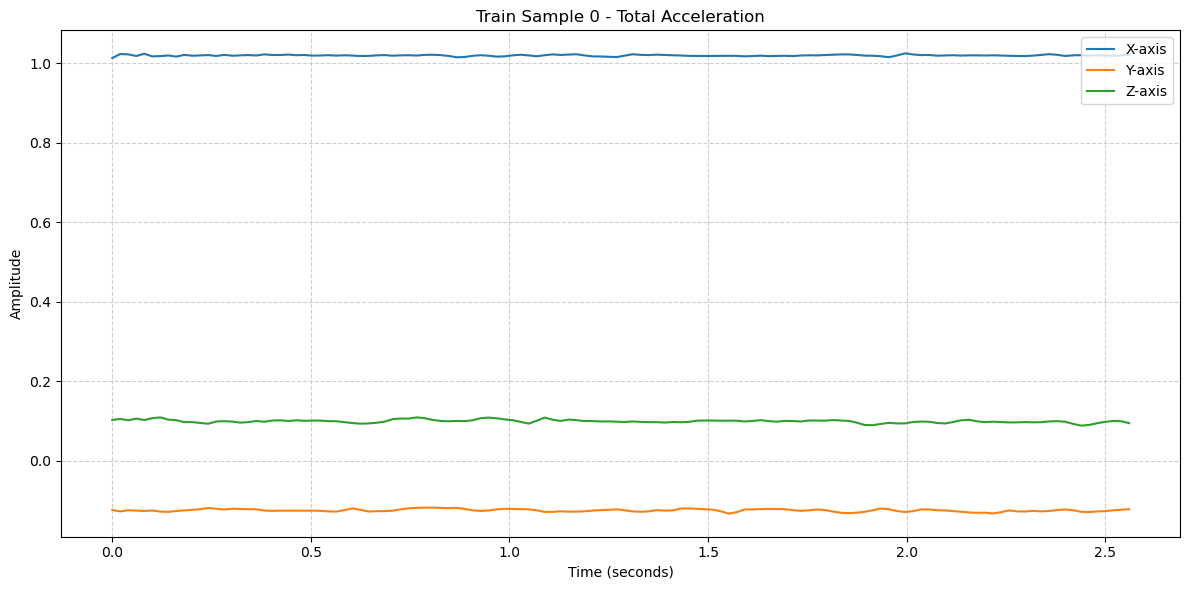

In [42]:
# Graph one sample of total accel data to visualize
plot_time_series(train_total_accel[0], title=f"Train Sample {0} - Total Acceleration")

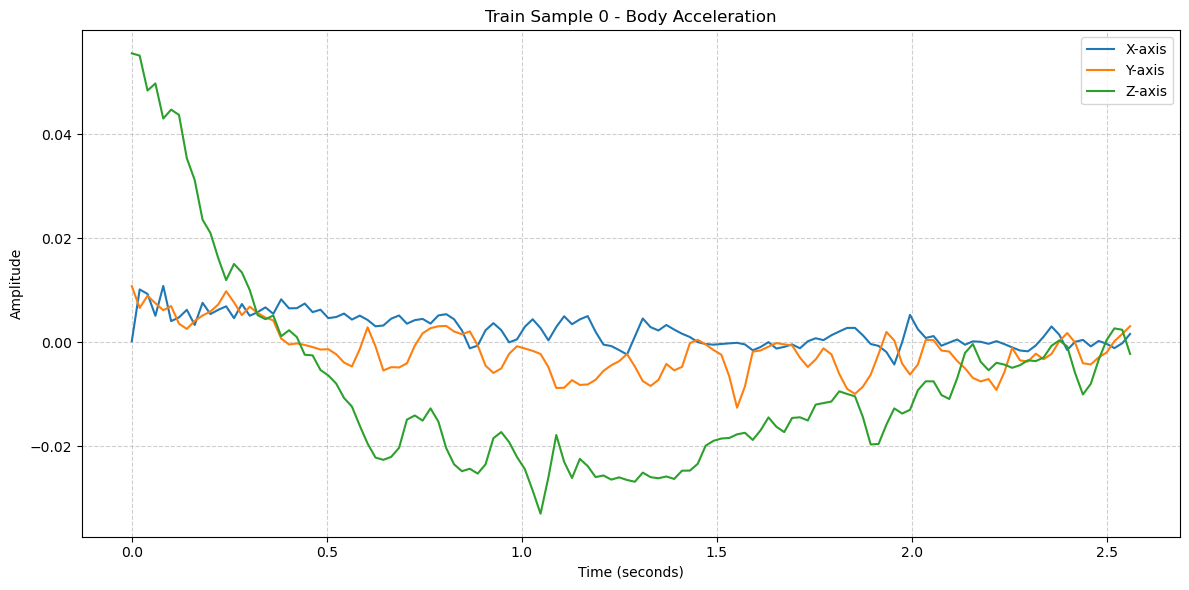

In [43]:
# Graph one sample of body accel data to visualize
plot_time_series(train_body_accel[0], title=f"Train Sample {0} - Body Acceleration")

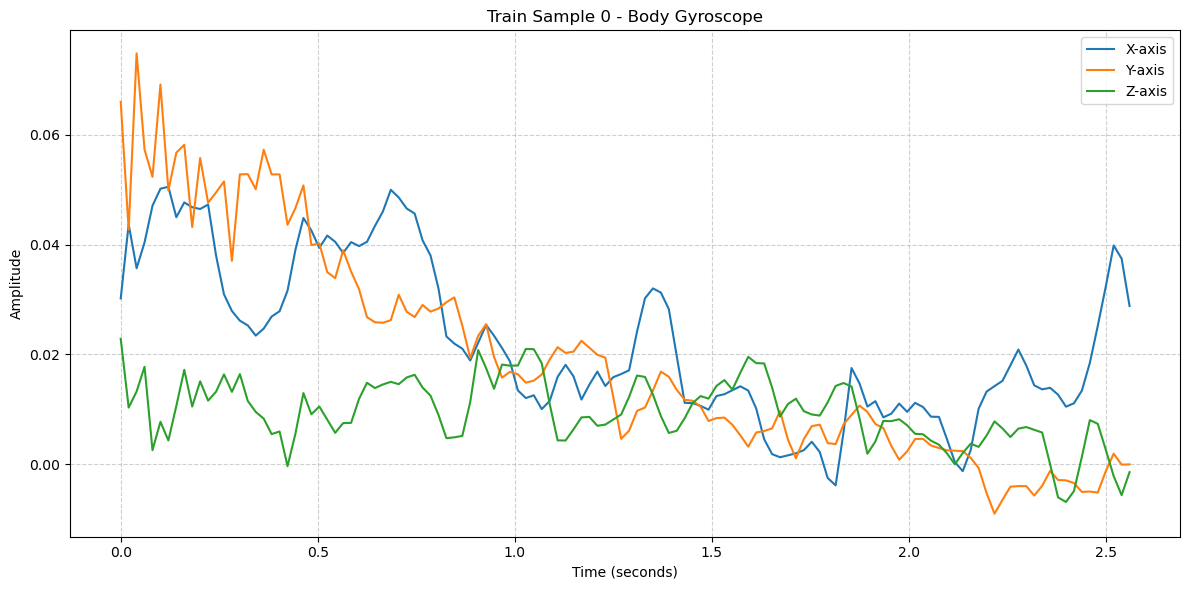

In [44]:
# Graph one sample of gyroscope data to visualize the time series
plot_time_series(train_body_gyro[0], title=f"Train Sample {0} - Body Gyroscope")

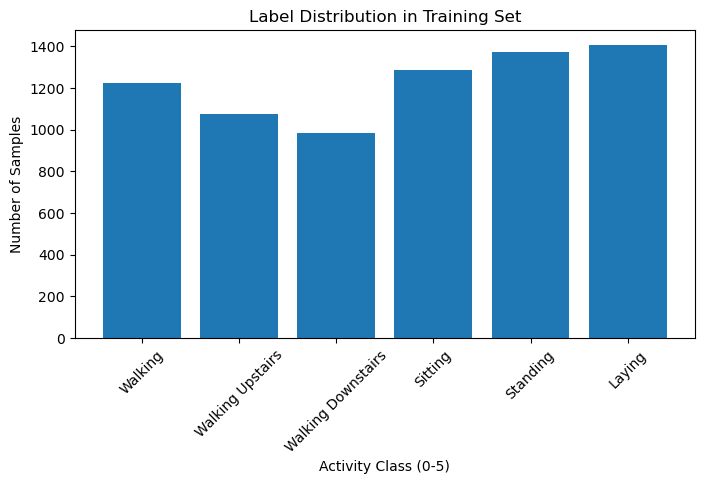

In [45]:
# Plot label distribution in training set to check for class imbalance
plt.figure(figsize=(8, 4))
label_counts = torch.bincount(train_labels)

plt.bar(range(6), label_counts.numpy())
plt.xlabel('Activity Class (0-5)')
plt.ylabel('Number of Samples')
plt.title('Label Distribution in Training Set')
plt.xticks(range(6), ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying'], rotation=45)
plt.show()

## Processing Data

In [46]:
# Calculate gravity acceleration by subtracting body acceleration from total acceleration.
train_gravity_accel = train_total_accel - train_body_accel
test_gravity_accel = test_total_accel - test_body_accel

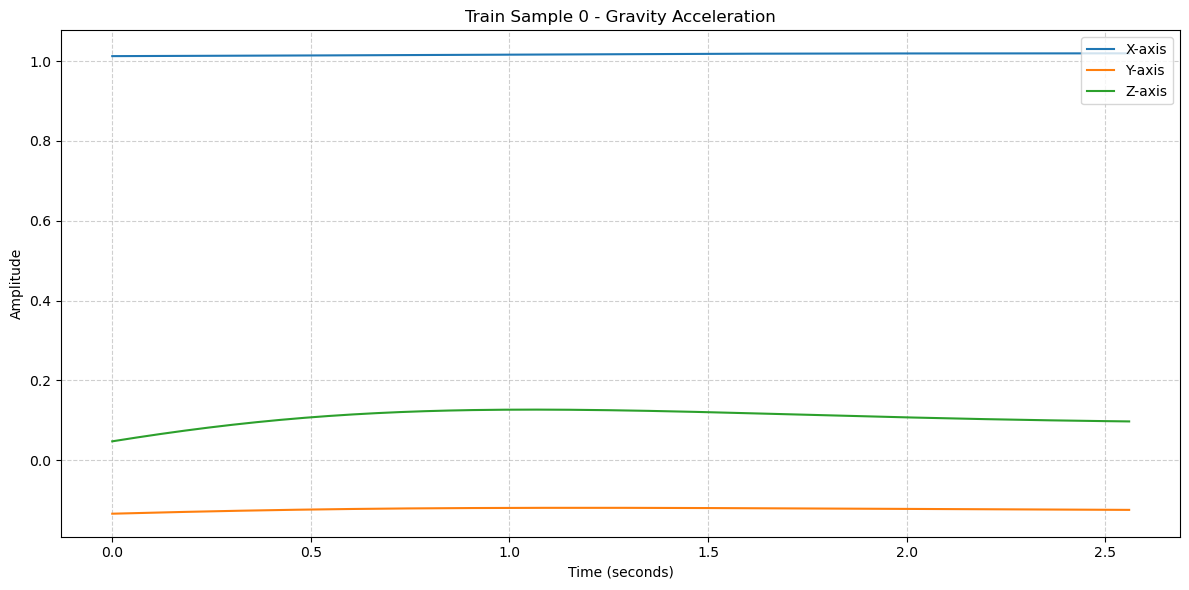

In [47]:
# Graph one sample gravity accel data to visualize
plot_time_series(train_gravity_accel[0], title=f"Train Sample {0} - Gravity Acceleration")

In [48]:
train_body_accel_spec = compute_spectrograms(train_body_accel)
test_body_accel_spec = compute_spectrograms(test_body_accel)

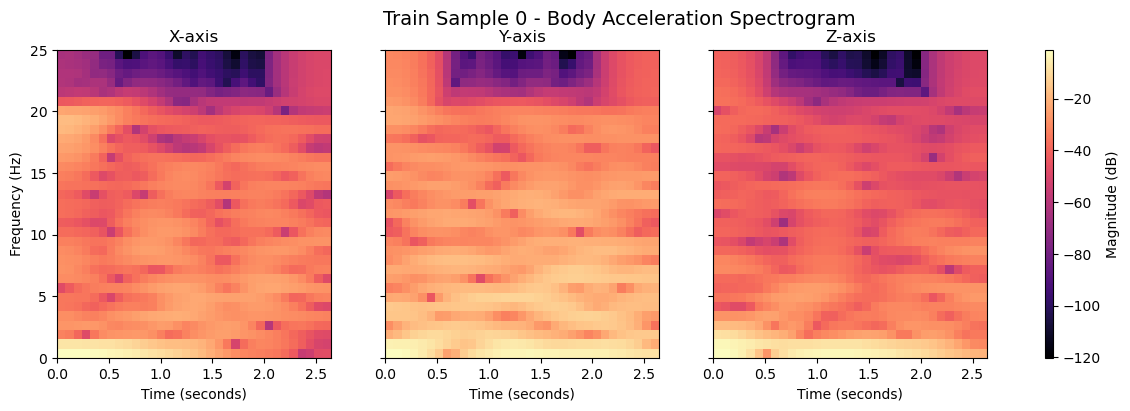

In [49]:
plot_precomputed_spectrogram(train_body_accel_spec[0], title=f"Train Sample {0} - Body Acceleration Spectrogram")

In [50]:
train_body_gyro_spec = compute_spectrograms(train_body_gyro)
test_body_gyro_spec = compute_spectrograms(test_body_gyro)

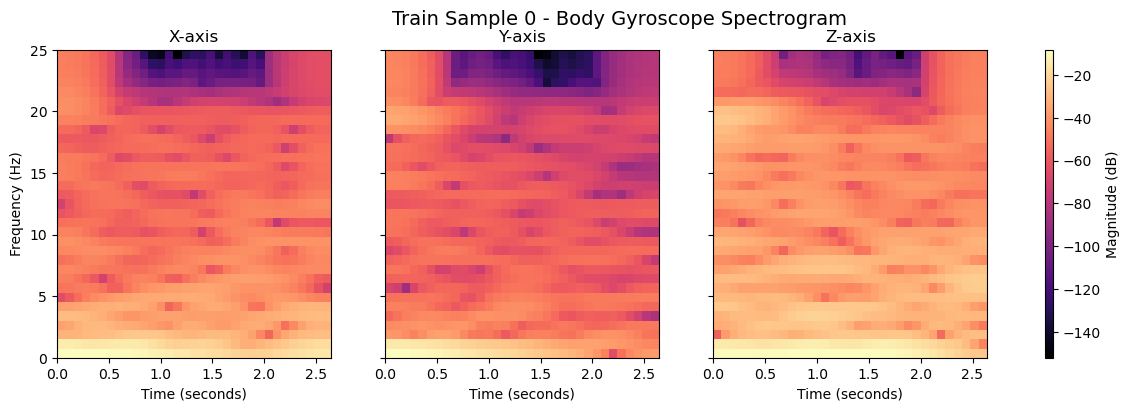

In [51]:
plot_precomputed_spectrogram(train_body_gyro_spec[0], title=f"Train Sample {0} - Body Gyroscope Spectrogram")

In [52]:
train_body_accel_spec_norm, test_body_accel_spec_norm = normalize_spectrograms(train_body_accel_spec, test_body_accel_spec)

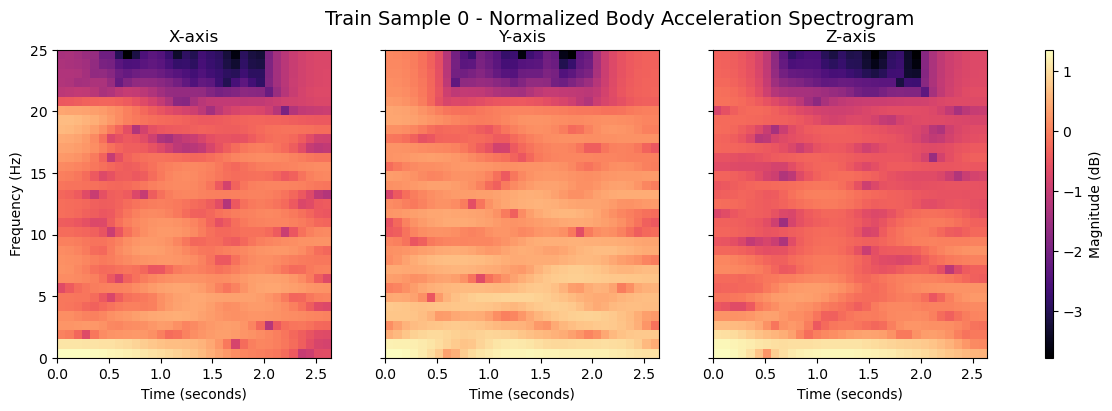

In [53]:
plot_precomputed_spectrogram(train_body_accel_spec_norm[0], title=f"Train Sample {0} - Normalized Body Acceleration Spectrogram")

In [54]:
train_body_gyro_spec_norm, test_body_gyro_spec_norm = normalize_spectrograms(train_body_gyro_spec, test_body_gyro_spec)

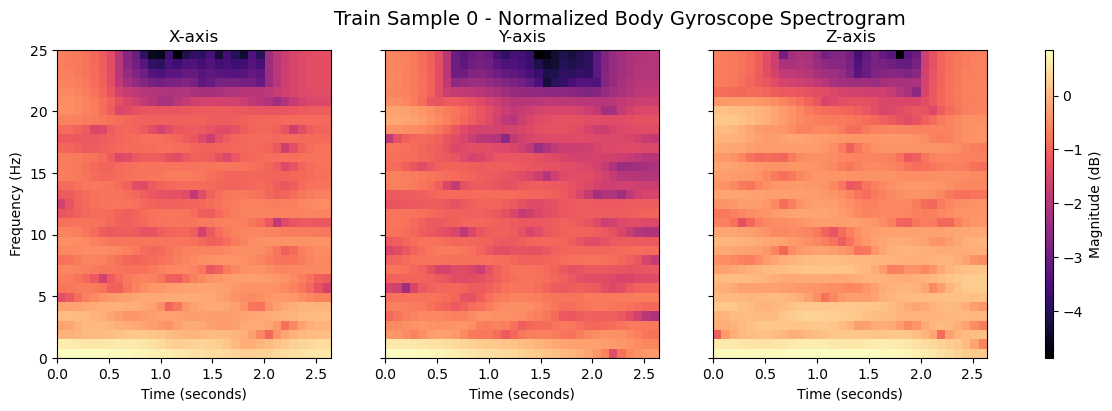

In [55]:
plot_precomputed_spectrogram(train_body_gyro_spec_norm[0], title=f"Train Sample {0} - Normalized Body Gyroscope Spectrogram")

## Saving Data

In [56]:
# Create processed data directory if it doesn't exist
os.makedirs('data/processed', exist_ok=True)

In [57]:
# Save the normalized train spectrograms and labels
torch.save(train_body_accel_spec_norm, 'data/processed/train_body_accel_spectrograms.pt')
torch.save(train_body_gyro_spec_norm, 'data/processed/train_body_gyro_spectrograms.pt')
torch.save(train_labels, 'data/processed/train_labels.pt')

In [58]:
# Save the normalized test spectrograms and labels
torch.save(test_body_accel_spec_norm, 'data/processed/test_body_accel_spectrograms.pt')
torch.save(test_body_gyro_spec_norm, 'data/processed/test_body_gyro_spectrograms.pt')
torch.save(test_labels, 'data/processed/test_labels.pt')

## Traditional ML Baseline (Random Forest)

In [59]:
rf_loader = HARDataLoader(root_dir='data/raw', CNN=False)

total_acc_train_rf, body_acc_train_rf, body_gyro_train_rf, y_train_rf = rf_loader.get_split('train')
X_train_rf = np.concatenate([total_acc_train_rf, body_acc_train_rf, body_gyro_train_rf], axis=2)

print(f"Train total accel shape: {total_acc_train_rf.shape}")
print(f"Train body accel shape: {body_acc_train_rf.shape}")
print(f"Train body gyro shape: {body_gyro_train_rf.shape}")
print(f"Train labels shape: {y_train_rf.shape}")
print(f"Train combined input shape: {X_train_rf.shape}")

total_acc_test_rf, body_acc_test_rf, body_gyro_test_rf, y_test_rf = rf_loader.get_split('test')
X_test_rf = np.concatenate([total_acc_test_rf, body_acc_test_rf, body_gyro_test_rf], axis=2)

print(f"Test total accel shape: {total_acc_test_rf.shape}")
print(f"Test body accel shape: {body_acc_test_rf.shape}")
print(f"Test body gyro shape: {body_gyro_test_rf.shape}")
print(f"Test labels shape: {y_test_rf.shape}")
print(f"Test combined input shape: {X_test_rf.shape}")

Train total accel shape: (7352, 128, 3)
Train body accel shape: (7352, 128, 3)
Train body gyro shape: (7352, 128, 3)
Train labels shape: (7352,)
Train combined input shape: (7352, 128, 9)
Test total accel shape: (2947, 128, 3)
Test body accel shape: (2947, 128, 3)
Test body gyro shape: (2947, 128, 3)
Test labels shape: (2947,)
Test combined input shape: (2947, 128, 9)


In [60]:
X_train_rf = X_train_rf.reshape(X_train_rf.shape[0], -1)
X_test_rf = X_test_rf.reshape(X_test_rf.shape[0], -1)

print(f"Flattened train shape: {X_train_rf.shape}")
print(f"Flattened test shape: {X_test_rf.shape}")

Flattened train shape: (7352, 1152)
Flattened test shape: (2947, 1152)


In [61]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf, y_train_rf)

y_pred = rf.predict(X_test_rf)

Test Accuracy: 0.8510

Classification Report:
              precision    recall  f1-score   support

     Walking       0.81      0.89      0.85       496
    Upstairs       0.85      0.78      0.81       471
  Downstairs       0.85      0.89      0.87       420
     Sitting       0.76      0.78      0.77       491
    Standing       0.83      0.76      0.80       532
      Laying       1.00      1.00      1.00       537

    accuracy                           0.85      2947
   macro avg       0.85      0.85      0.85      2947
weighted avg       0.85      0.85      0.85      2947

Confusion Matrix:


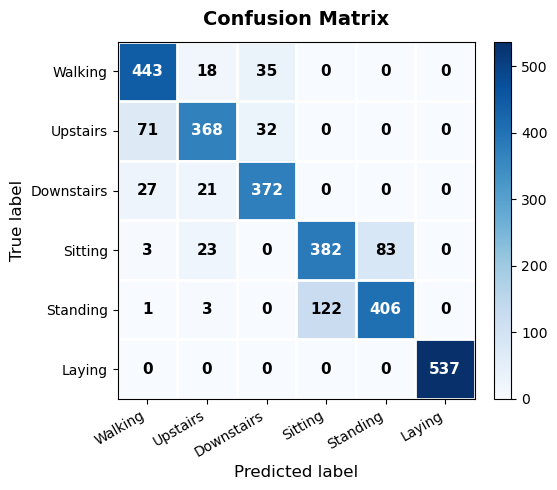

In [62]:
# Evaluate
class_names = ["Walking", "Upstairs", "Downstairs", "Sitting", "Standing", "Laying"]
print(f"Test Accuracy: {accuracy_score(y_test_rf, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test_rf, y_pred, target_names=class_names))
print("Confusion Matrix:")
cm = confusion_matrix(y_test_rf, y_pred)
plot_confusion_matrix(cm, class_names, title="Confusion Matrix")

## CNN Model

In [102]:
train_body_accel_spec = torch.load("data/processed/train_body_accel_spectrograms.pt")
train_body_gyro_spec = torch.load("data/processed/train_body_gyro_spectrograms.pt")
train_labels = torch.load("data/processed/train_labels.pt")

test_body_accel_spec = torch.load("data/processed/test_body_accel_spectrograms.pt")
test_body_gyro_spec = torch.load("data/processed/test_body_gyro_spectrograms.pt")
test_labels = torch.load("data/processed/test_labels.pt")

print("Train body accel spec shape:", train_body_accel_spec.shape)
print("Train body gyro spec shape:", train_body_gyro_spec.shape)
print("Train labels shape:", train_labels.shape)

print("Test body accel spec shape:", test_body_accel_spec.shape)
print("Test body gyro spec shape:", test_body_gyro_spec.shape)
print("Test labels shape:", test_labels.shape)

Train body accel spec shape: torch.Size([7352, 3, 33, 33])
Train body gyro spec shape: torch.Size([7352, 3, 33, 33])
Train labels shape: torch.Size([7352])
Test body accel spec shape: torch.Size([2947, 3, 33, 33])
Test body gyro spec shape: torch.Size([2947, 3, 33, 33])
Test labels shape: torch.Size([2947])


C:\Users\Noahs\AppData\Local\Temp\ipykernel_29412\2277575465.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_body_accel_spec = torch.load("data/processed/train_bod

In [ ]:
train_spec = torch.cat([train_body_accel_spec, train_body_gyro_spec], dim=1)
test_spec = torch.cat([test_body_accel_spec, test_body_gyro_spec], dim=1)

print("Combined train input shape:", train_spec.shape)
print("Combined test input shape:", test_spec.shape)

Combined train input shape: torch.Size([7352, 6, 33, 33])
Combined test input shape: torch.Size([2947, 6, 33, 33])


In [ ]:
batch_size = 64

train_dataset = TensorDataset(train_spec, train_labels)
test_dataset = TensorDataset(test_spec, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 115
Number of test batches: 47


In [ ]:
class ActivitySpectrogram(nn.Module):
    def __init__(self):
        super().__init__()

        # Input
        self.conv1 = nn.Conv2d(in_channels=6, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.25)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout(0.3)

        # Pooling
        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.drop_fc = nn.Dropout(0.4)
        self.fc2 = nn.Linear(128, 6)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.drop1(x)

        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.drop2(x)

        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.drop3(x)

        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ActivitySpectrogram().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

print(model)

Using device: cpu
ActivitySpectrogram(
  (conv1): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.2, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop3): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (drop_fc): Drop

In [ ]:
num_epochs = 20

train_loss_history = []
test_loss_history = []
train_acc_history = []
test_acc_history = []

for epoch in range(num_epochs):
    # Train Data
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train

    train_loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)

    # Test Data
    model.eval()
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = correct_test / total_test

    test_loss_history.append(epoch_test_loss)
    test_acc_history.append(epoch_test_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Test Loss: {epoch_test_loss:.4f} | "
        f"Test Acc: {epoch_test_acc:.4f}"
    )

Epoch 1/20 | Train Loss: 1.0100 | Train Acc: 0.5264 | Test Loss: 0.6724 | Test Acc: 0.7414
Epoch 2/20 | Train Loss: 0.4884 | Train Acc: 0.8157 | Test Loss: 0.6119 | Test Acc: 0.7581
Epoch 3/20 | Train Loss: 0.3414 | Train Acc: 0.8732 | Test Loss: 0.3173 | Test Acc: 0.8829
Epoch 4/20 | Train Loss: 0.2893 | Train Acc: 0.8935 | Test Loss: 0.4640 | Test Acc: 0.8276
Epoch 5/20 | Train Loss: 0.2634 | Train Acc: 0.9018 | Test Loss: 0.3953 | Test Acc: 0.8568
Epoch 6/20 | Train Loss: 0.2308 | Train Acc: 0.9166 | Test Loss: 0.2399 | Test Acc: 0.9033
Epoch 7/20 | Train Loss: 0.2266 | Train Acc: 0.9185 | Test Loss: 0.2195 | Test Acc: 0.9162
Epoch 8/20 | Train Loss: 0.1916 | Train Acc: 0.9293 | Test Loss: 0.2055 | Test Acc: 0.9203
Epoch 9/20 | Train Loss: 0.1843 | Train Acc: 0.9302 | Test Loss: 0.1987 | Test Acc: 0.9253
Epoch 10/20 | Train Loss: 0.1687 | Train Acc: 0.9376 | Test Loss: 0.1974 | Test Acc: 0.9264
Epoch 11/20 | Train Loss: 0.1591 | Train Acc: 0.9433 | Test Loss: 0.1820 | Test Acc: 0.92

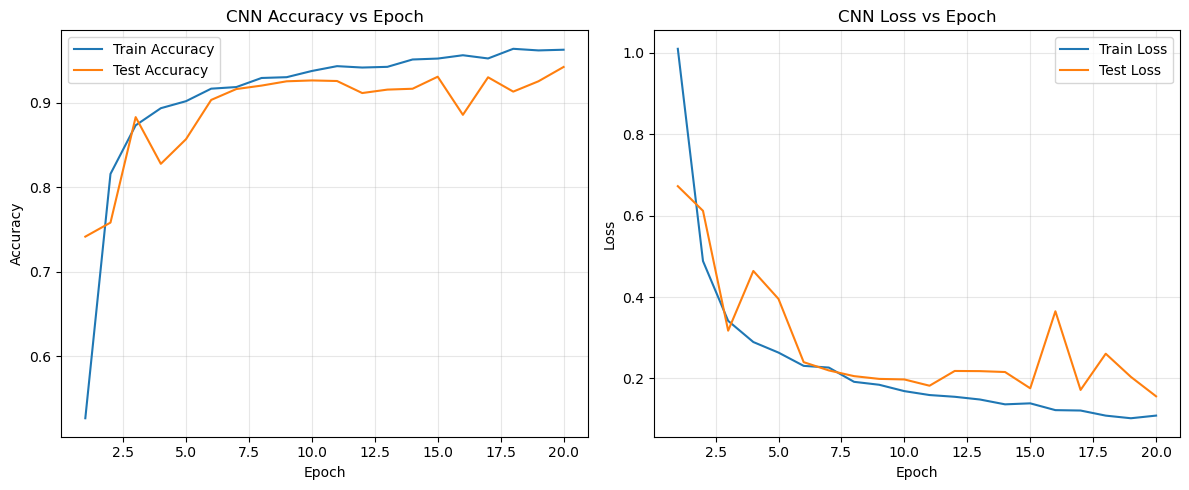

In [112]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc_history, label='Train Accuracy')
plt.plot(epochs, test_acc_history, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy vs Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss_history, label='Train Loss')
plt.plot(epochs, test_loss_history, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss vs Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [113]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

activity_names = [
    "Walking",
    "Upstairs",
    "Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=activity_names))

Confusion Matrix:
[[469   6  21   0   0   0]
 [  1 450  20   0   0   0]
 [  4   3 413   0   0   0]
 [  0   1   0 445  30  15]
 [  0   0   0  19 501  12]
 [  0   0   1  28   9 499]]

Classification Report:
              precision    recall  f1-score   support

     Walking       0.99      0.95      0.97       496
    Upstairs       0.98      0.96      0.97       471
  Downstairs       0.91      0.98      0.94       420
     Sitting       0.90      0.91      0.91       491
    Standing       0.93      0.94      0.93       532
      Laying       0.95      0.93      0.94       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



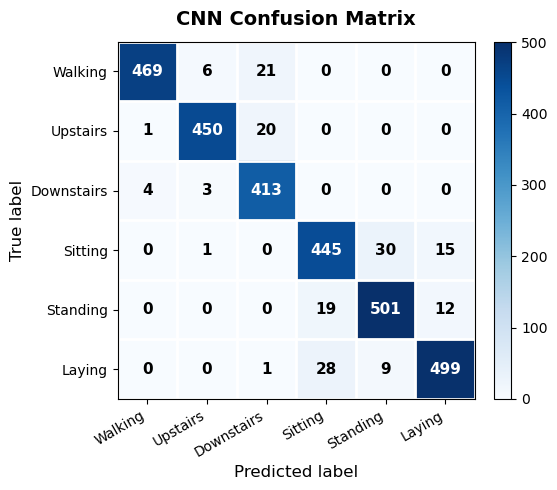

In [111]:
plot_confusion_matrix(cm, activity_names, title="CNN Confusion Matrix")